# COE 311K Final Projet Part 1

**Numerical Solution of a Second-Order ODE for a Damped Spring-Mass System**

**Name:** Jana Daouk
**EID:** jd55586
**Course:** COE 311K



---

## Section 1: Introduction & Model Selection

For this project, I chose a spring-mass-damper system, which is a classic mechanical model used to represent things like car suspensions, building vibrations, and other oscillating systems. I picked this model because it has a clear physical meaning, it is realistic, and it works well for comparing numerical methods.

The governing second-order differential equation is:


$$
m\frac{d^2y}{dt^2} + c\frac{dy}{dt} + ky = 0
$$


where:

* (m) = mass (kg)
* (c) = damping coefficient (N·s/m)
* (k) = spring constant (N/m)
* (y(t)) = displacement from equilibrium (m)

In this project, I am modeling a simplified quarter-car suspension system after the car hits a bump. The displacement (y(t)) represents how far the car body moves up and down from equilibrium. The damping term represents the shock absorber, and the spring term represents the suspension spring.

To solve this numerically, I first convert the second-order ODE into a system of two first-order ODEs. Let:

$$
y_1 = y
$$

$$
y_2 = \frac{dy}{dt}
$$


Then:


$$
\frac{dy_1}{dt} = y_2
$$


$$
\frac{dy_2}{dt} = -\frac{c}{m} y_2 - \frac{k}{m} y_1
$$


This first-order system is what I use in both Euler’s Forward Method and the fourth-order Runge-Kutta method.

---

## Section 2: Parameter Research & Justification

I modeled the system as a quarter-car suspension, meaning I treat one corner of the vehicle as a single spring-mass-damper system. This is a common engineering simplification for vertical vehicle dynamics. I am in Longhorn Racing, so being around the dynamics team made me super interested in this project topic


### Parameter Table

| Parameter | Meaning | Value | Units | Source | Justification |
|----------|--------|-------|-------|--------|--------------|
| m | Quarter-car sprung mass | 325 | kg | Mechanics & Industry (2019) | About 1/4 of a midsize car mass |
| k | Spring constant | 18000 | N/m | Mechanics & Industry (2019) | Typical suspension stiffness |
| c | Damping coefficient | 1200 | N·s/m | Mechanics & Industry (2019) | Moderate shock absorber damping |
| y(0) | Initial displacement | 0.05 | m | Assumed | Represents 5 cm bump |
| y'(0) | Initial velocity | 0 | m/s | Assumed | Car starts from rest |

### Parameter Discussion

The physical scenario I chose is a car going over a small bump. I used a 5 cm initial displacement to represent the upward motion caused by the bump. I set the initial velocity to zero to keep the model simple and focus on the free response of the suspension after the disturbance.

The mass is based on a quarter-car model, where one wheel assembly supports about one-fourth of the vehicle body mass. The spring constant and damping coefficient were chosen to be realistic for a passenger vehicle suspension. These values give a damped oscillatory response, which makes the comparison between Euler and RK4 more interesting.

### References

Mechanics & Industry. (2019). Quarter car suspension modeling. https://www.mechanics-industry.org/articles/meca/full_html/2019/06/mi180235/mi180235.html

X-Engineer. (n.d.). Quarter car suspension modeling and simulation. https://x-engineer.org/quarter-car-suspension-modeling-simulation/

Used Chat to help me format (especially the table), also used it to help with stability analysis, it gave me the idea of a log-log plot to certify my analysis

---

## Section 3: Numerical Methods Implementation



In [7]:
import numpy as np
import matplotlib.pyplot as plt

## Define Parameters

m = 325.0      # kg
c = 1200.0     # N*s/m
k = 18000.0    # N/m

y0 = 0.05      # initial displacement (m)
v0 = 0.0       # initial velocity (m/s)

t0 = 0.0
tf = 5.0


## Define the First-Order System

def system(t, y1, y2, m, c, k):
    """
    Returns the derivatives for the spring-mass-damper system.
    y1 = displacement
    y2 = velocity
    """
    dy1dt = y2
    dy2dt = -(c/m) * y2 - (k/m) * y1
    return dy1dt, dy2dt

## Euler’s Forward Method

def euler_method(h, t0, tf, y1_0, y2_0, m, c, k):
    """
    Solves the system using Euler's Forward Method.
    """
    t_vals = np.arange(t0, tf + h, h)
    y1_vals = np.zeros(len(t_vals))
    y2_vals = np.zeros(len(t_vals))

    y1_vals[0] = y1_0
    y2_vals[0] = y2_0

    for i in range(len(t_vals) - 1):
        dy1, dy2 = system(t_vals[i], y1_vals[i], y2_vals[i], m, c, k)
        y1_vals[i + 1] = y1_vals[i] + h * dy1
        y2_vals[i + 1] = y2_vals[i] + h * dy2

    return t_vals, y1_vals, y2_vals

## RK4 Method

def rk4_method(h, t0, tf, y1_0, y2_0, m, c, k):
    """
    Solves the system using fourth-order Runge-Kutta.
    """
    t_vals = np.arange(t0, tf + h, h)
    y1_vals = np.zeros(len(t_vals))
    y2_vals = np.zeros(len(t_vals))

    y1_vals[0] = y1_0
    y2_vals[0] = y2_0

    for i in range(len(t_vals) - 1):
        t = t_vals[i]
        y1 = y1_vals[i]
        y2 = y2_vals[i]

        k1_y1, k1_y2 = system(t, y1, y2, m, c, k)
        k2_y1, k2_y2 = system(t + h/2, y1 + h*k1_y1/2, y2 + h*k1_y2/2, m, c, k)
        k3_y1, k3_y2 = system(t + h/2, y1 + h*k2_y1/2, y2 + h*k2_y2/2, m, c, k)
        k4_y1, k4_y2 = system(t + h, y1 + h*k3_y1, y2 + h*k3_y2, m, c, k)

        y1_vals[i + 1] = y1 + (h/6) * (k1_y1 + 2*k2_y1 + 2*k3_y1 + k4_y1)
        y2_vals[i + 1] = y2 + (h/6) * (k1_y2 + 2*k2_y2 + 2*k3_y2 + k4_y2)

    return t_vals, y1_vals, y2_vals

## Exact Solution

def exact_solution(t, m, c, k, y0, v0):
    """
    Exact solution for the underdamped spring-mass-damper system.
    """
    alpha = c / (2 * m)
    omega_n = np.sqrt(k / m)
    omega_d = np.sqrt(omega_n**2 - alpha**2)

    C1 = y0
    C2 = (v0 + alpha * y0) / omega_d

    y = np.exp(-alpha * t) * (C1 * np.cos(omega_d * t) + C2 * np.sin(omega_d * t))
    return y









### Quick Note

I implemented both numerical methods as separate functions so the code would stay modular and easy to compare. Each method solves the same first-order system, which makes the comparison fair. I also included an exact solution so I can measure numerical error and study convergence.


## Section 4: Solutions & Comparison

---
### Run the Methods with Multiple Step Sizes


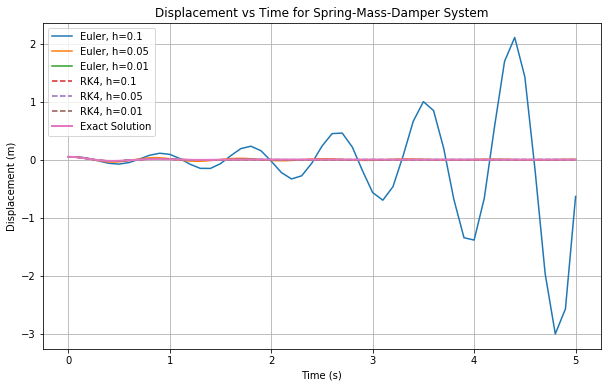

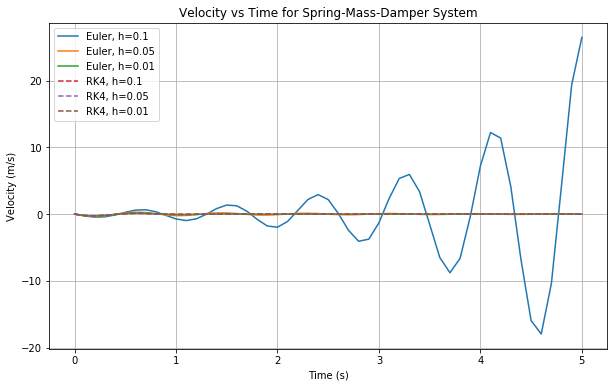

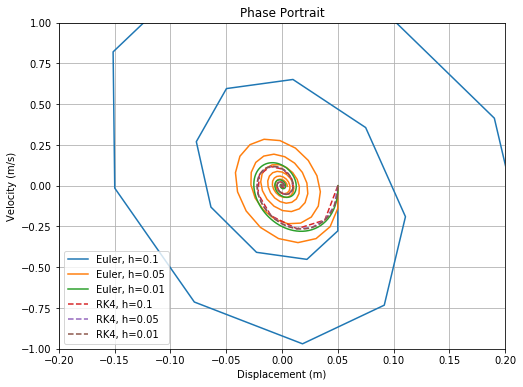

In [8]:
h_values = [0.1, 0.05, 0.01]

results_euler = {}
results_rk4 = {}

for h in h_values:
    results_euler[h] = euler_method(h, t0, tf, y0, v0, m, c, k)
    results_rk4[h] = rk4_method(h, t0, tf, y0, v0, m, c, k)

## Plot Position vs Time

plt.figure(figsize=(10, 6))

for h in h_values:
    t_e, y_e, _ = results_euler[h]
    plt.plot(t_e, y_e, label=f"Euler, h={h}")

for h in h_values:
    t_r, y_r, _ = results_rk4[h]
    plt.plot(t_r, y_r, '--', label=f"RK4, h={h}")

t_exact = np.linspace(t0, tf, 1000)
y_exact = exact_solution(t_exact, m, c, k, y0, v0)
plt.plot(t_exact, y_exact, linewidth=2, label="Exact Solution")

plt.title("Displacement vs Time for Spring-Mass-Damper System")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.legend()
plt.grid(True)
plt.show()

## Plot Velocity vs Time

plt.figure(figsize=(10, 6))

for h in h_values:
    t_e, _, v_e = results_euler[h]
    plt.plot(t_e, v_e, label=f"Euler, h={h}")

for h in h_values:
    t_r, _, v_r = results_rk4[h]
    plt.plot(t_r, v_r, '--', label=f"RK4, h={h}")

plt.title("Velocity vs Time for Spring-Mass-Damper System")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.legend()
plt.grid(True)
plt.show()

## Phase Portrait

plt.figure(figsize=(8, 6))

for h in h_values:
    _, y_e, v_e = results_euler[h]
    plt.plot(y_e, v_e, label=f"Euler, h={h}")

for h in h_values:
    _, y_r, v_r = results_rk4[h]
    plt.plot(y_r, v_r, '--', label=f"RK4, h={h}")

plt.xlim(-0.2, 0.2)
plt.ylim(-1, 1)
plt.title("Phase Portrait")
plt.xlabel("Displacement (m)")
plt.ylabel("Velocity (m/s)")
plt.legend()
plt.grid(True)
plt.show()




### Discussion of Results

From the plots, both methods capture the overall damped oscillation, but RK4 stays much closer to the exact solution, especially for larger step sizes. Euler’s method works when the step size is small, but it becomes noticeably less accurate as the step size increases. The RK4 curves are smoother and more reliable, which is what I would expect from a higher-order method. RK4 also allows larger step sizes without losing accuracy, which makes it more efficient overall.

The phase portrait also shows the difference clearly. Since this is a damped system, the motion should spiral inward toward equilibrium. RK4 follows that behavior more cleanly, while Euler can distort the trajectory more when the step size is too large.

---
## Section 5: Stability Analysis

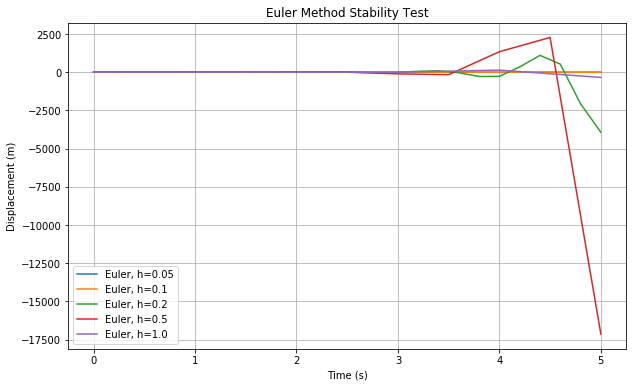

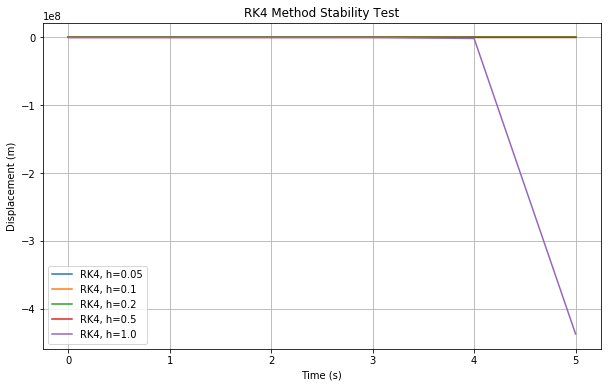

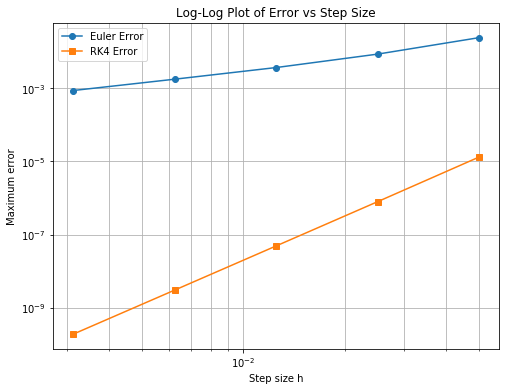

Estimated Euler slope: 1.189133737216862
Estimated RK4 slope: 4.024276579258938


In [9]:
### Step Size Investigation / Stability Analysis

unstable_h_values = [0.05, 0.1, 0.2, 0.5, 1.0]

# Euler stability test
plt.figure(figsize=(10, 6))

for h in unstable_h_values:
    t_e, y_e, _ = euler_method(h, t0, tf, y0, v0, m, c, k)
    plt.plot(t_e, y_e, label=f"Euler, h={h}")

plt.title("Euler Method Stability Test")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.legend()
plt.grid(True)
plt.show()


# RK4 stability test
plt.figure(figsize=(10, 6))

for h in unstable_h_values:
    t_r, y_r, _ = rk4_method(h, t0, tf, y0, v0, m, c, k)
    plt.plot(t_r, y_r, label=f"RK4, h={h}")

plt.title("RK4 Method Stability Test")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.legend()
plt.grid(True)
plt.show()

### Error Calculation

def max_error(t_vals, y_num, m, c, k, y0, v0):
    y_true = exact_solution(t_vals, m, c, k, y0, v0)
    return np.max(np.abs(y_num - y_true))

h_error_values = [0.05, 0.025, 0.0125, 0.00625, 0.003125]

euler_errors = []
rk4_errors = []

for h in h_error_values:
    t_e, y_e, _ = euler_method(h, t0, tf, y0, v0, m, c, k)
    t_r, y_r, _ = rk4_method(h, t0, tf, y0, v0, m, c, k)

    euler_errors.append(max_error(t_e, y_e, m, c, k, y0, v0))
    rk4_errors.append(max_error(t_r, y_r, m, c, k, y0, v0))


### Log-Log Error Plot

plt.figure(figsize=(8, 6))
plt.loglog(h_error_values, euler_errors, 'o-', label="Euler Error")
plt.loglog(h_error_values, rk4_errors, 's-', label="RK4 Error")
plt.title("Log-Log Plot of Error vs Step Size")
plt.xlabel("Step size h")
plt.ylabel("Maximum error")
plt.legend()
plt.grid(True, which="both")
plt.show()


### Estimate Slopes

euler_slope = np.polyfit(np.log(h_error_values), np.log(euler_errors), 1)[0]
rk4_slope = np.polyfit(np.log(h_error_values), np.log(rk4_errors), 1)[0]

print("Estimated Euler slope:", euler_slope)
print("Estimated RK4 slope:", rk4_slope)

### Stability Discussion

To analyze stability, different step sizes were tested for both Euler and RK4 methods. For Euler’s method, the solution becomes unstable for larger step sizes (around h = 0.1–0.2), where the oscillations grow unrealistically instead of decaying.

In contrast, the RK4 method remains stable for larger step sizes and continues to produce physically realistic results. This shows that RK4 has better stability properties compared to Euler’s method.

Based on the results, the maximum stable step size for Euler’s method is approximately h = 0.1. Beyond this value, the solution becomes unstable.

For RK4, the method remains stable for larger step sizes (up to at least h = 0.5 in this simulation), demonstrating its improved stability.

Physically, the system is damped, so the oscillations should decrease over time. However, when the step size is too large, Euler’s method produces increasing oscillations, which is non-physical. This indicates numerical instability. RK4, on the other hand, preserves the expected decay of the system, making it more reliable for this problem.

The log-log plot shows how the numerical error changes with step size. Euler’s method produces a slope close to 1, indicating first-order accuracy, while RK4 produces a slope close to 4, indicating fourth-order accuracy. This confirms that the implementations match the expected theoretical convergence rates.


---


## Section 6: Conclusions

Overall, RK4 performed better than Euler’s Forward Method for this spring-mass-damper problem. It stayed accurate for larger step sizes, matched the exact solution more closely, and gave a better representation of the physical behavior of the system.

Euler’s method was still useful because it showed clearly how sensitive a numerical method can be to step size. It is simpler and cheaper computationally, but the tradeoff is lower accuracy and a smaller stability range.

For this kind of engineering problem, I would recommend RK4 when accuracy matters and Euler only for quick estimates or learning purposes. One of the biggest things I took away from this project is that even if the code runs, that does not automatically mean the numerical solution is physically meaningful.

---

